In [18]:
from typing import Literal

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import scanpy as sc
import spatialdata_io
import spatialdata_plot
import squidpy as sq
import spatialdata as sd

from anndata import AnnData
from spatialdata import SpatialData
from spatialdata._core.query.relational_query import _get_unique_label_values_as_index
from spatialdata.datasets import blobs
from spatialdata.models import TableModel
from spatialdata.transformations import Affine, set_transformation
from spatialdata_io.experimental import from_legacy_anndata, to_legacy_anndata
sdata = sd.read_zarr("../dati/c26t16/c26t16.zarr")



In [19]:
sdata

SpatialData object with:
├── Images
│     ├── 'C26T16_GFP': MultiscaleSpatialImage[cyx] (3, 8057, 8991), (3, 4028, 4495), (3, 2014, 2247), (3, 1007, 1123), (3, 503, 561)
│     ├── 'C26T16_WGA': MultiscaleSpatialImage[cyx] (3, 8057, 8991), (3, 4028, 4495), (3, 2014, 2247), (3, 1007, 1123), (3, 503, 561)
│     ├── 'C26T16_bungaro': MultiscaleSpatialImage[cyx] (3, 8057, 8991), (3, 4028, 4495), (3, 2014, 2247), (3, 1007, 1123), (3, 503, 561)
│     ├── 'C26T16_dapi': MultiscaleSpatialImage[cyx] (3, 8057, 8991), (3, 4028, 4495), (3, 2014, 2247), (3, 1007, 1123), (3, 503, 561)
│     ├── 'C26T16_full_image': MultiscaleSpatialImage[cyx] (3, 15273, 14901), (3, 7636, 7450), (3, 3818, 3725), (3, 1909, 1862), (3, 954, 931)
│     ├── 'C26T16_hires_image': SpatialImage[cyx] (3, 2000, 1951)
│     ├── 'C26T16_lowres_image': SpatialImage[cyx] (3, 600, 586)
│     └── 'C26T16_merge': MultiscaleSpatialImage[cyx] (3, 8057, 8991), (3, 4028, 4495), (3, 2014, 2247), (3, 1007, 1123), (3, 503, 561)
├── Shapes
│ 

In [20]:
sq.pl.spatial_scatter(sdata)

AttributeError: 'SpatialData' object has no attribute '_sanitize'

INFO     Dropping coordinate system 'downscaled_lowres' since it doesn't have relevant elements.                   
INFO     Dropping coordinate system 'downscaled_hires' since it doesn't have relevant elements.                    
INFO     Dropping coordinate system 'downscaled_lowres' since it doesn't have relevant elements.                   
INFO     Dropping coordinate system 'downscaled_hires' since it doesn't have relevant elements.                    


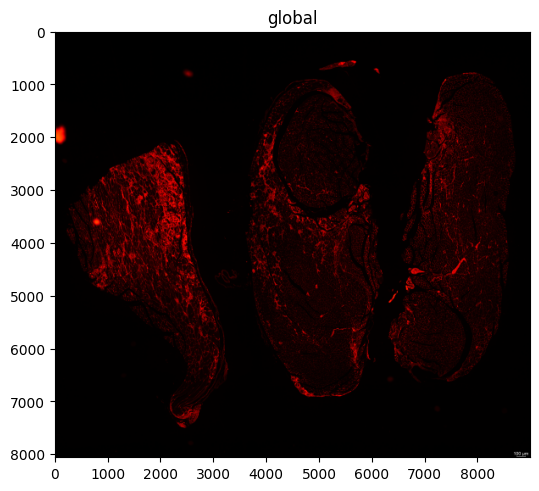

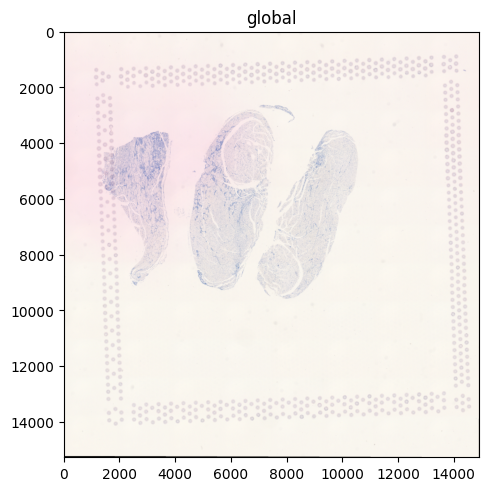

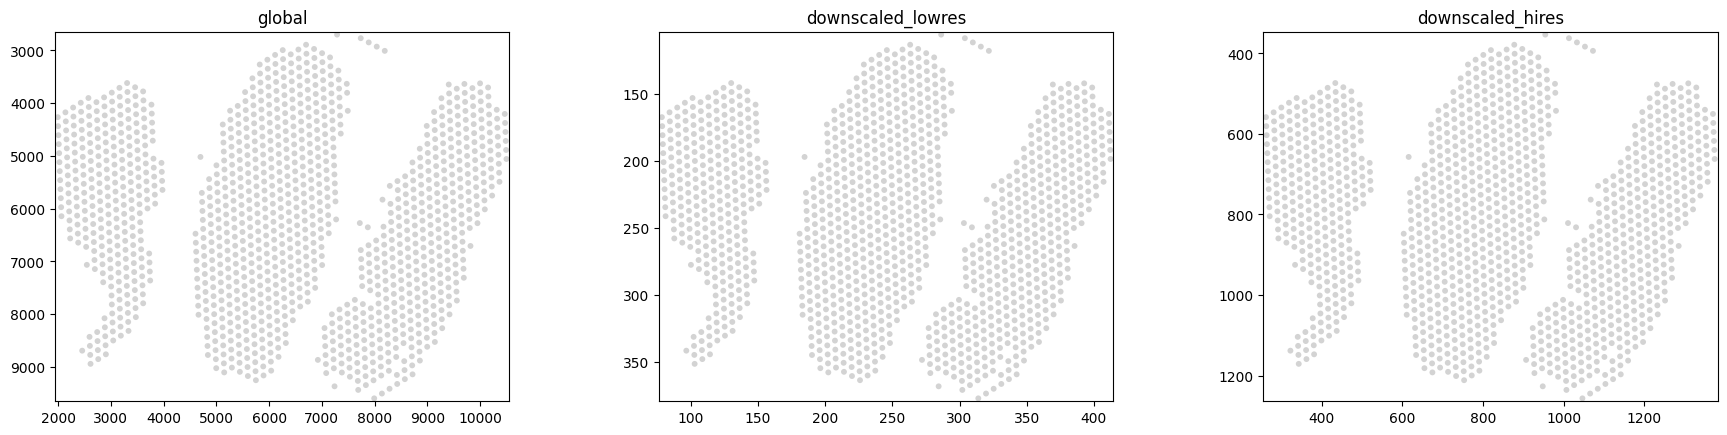

In [21]:
sdata.pl.render_images(elements="C26T16_WGA").pl.show()

sdata.pl.render_images(elements="C26T16_full_image").pl.show()
sdata.pl.render_shapes("C26T16", channel = "global").pl.show()

In [22]:
full_image = sdata.images['C26T16_full_image'].data

# Estrai le forme (spot)
spots = sdata['C26T16']

# Creazione della figura
fig, ax = plt.subplots(figsize=(10, 10))

# Mostra l'immagine full resolution
ax.imshow(full_image[0], cmap='gray')  # Immagine nel primo canale (0), cambia se vuoi altro canale

# Sovrapponi gli spot
spots.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1)

# Imposta il titolo
ax.set_title('C26T16 Full Image with Spots')

# Mostra la figura
plt.show()

AttributeError: 'MultiscaleSpatialImage' object has no attribute 'data'

In [23]:
sdata.table

/tmp/ipykernel_59007/4181403938.py:1: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  sdata.table


AnnData object with n_obs × n_vars = 1239 × 19465
    obs: 'in_tissue', 'array_row', 'array_col', 'spot_id', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'spatialdata_attrs'
    obsm: 'spatial'

In [24]:
sdata2 = SpatialData(images = {"C26T17_GFP": sdata["C26T17_GFP"], "C26T17_WGA": sdata["C26T17_WGA"], 
                               "C26T17_dapi": sdata["C26T17_dapi"], "C26T17_merge": sdata["C26T17_merge"]},
                    shapes = {"C26T17": sdata["C26T17"]},
                    table = sdata.table
                    )
sdata2

KeyError: "Could not find element with name 'C26T17_GFP'"

In [14]:
from napari_spatialdata import Interactive
Interactive(sdata2)


NameError: name 'sdata2' is not defined

In [6]:
sdata = sdata2
rename_dict = {"aligned": "global"}
sdata.rename_coordinate_systems(rename_dict)

# from spatialdata.transformations import (
#     Affine,
#     Identity,
#     MapAxis,
#     Scale,
#     Sequence,
#     Translation,
#     get_transformation,
#     get_transformation_between_coordinate_systems,
#     set_transformation,
# )

# set_transformation(sdata.images["C26T17_GFP"], Identity(), "global")
# set_transformation(sdata.images["C26T17_WGA"], Identity(), "global")
# set_transformation(sdata.images["C26T17_dapi"], Identity(), "global")
# set_transformation(sdata.images["C26T17_merge"], Identity(), "global")
# set_transformation(sdata.shapes["C26T17"], Identity(), "global")


In [16]:
sdata

SpatialData object with:
├── Images
│     ├── 'C26T16_GFP': MultiscaleSpatialImage[cyx] (3, 8057, 8991), (3, 4028, 4495), (3, 2014, 2247), (3, 1007, 1123), (3, 503, 561)
│     ├── 'C26T16_WGA': MultiscaleSpatialImage[cyx] (3, 8057, 8991), (3, 4028, 4495), (3, 2014, 2247), (3, 1007, 1123), (3, 503, 561)
│     ├── 'C26T16_bungaro': MultiscaleSpatialImage[cyx] (3, 8057, 8991), (3, 4028, 4495), (3, 2014, 2247), (3, 1007, 1123), (3, 503, 561)
│     ├── 'C26T16_dapi': MultiscaleSpatialImage[cyx] (3, 8057, 8991), (3, 4028, 4495), (3, 2014, 2247), (3, 1007, 1123), (3, 503, 561)
│     ├── 'C26T16_full_image': MultiscaleSpatialImage[cyx] (3, 15273, 14901), (3, 7636, 7450), (3, 3818, 3725), (3, 1909, 1862), (3, 954, 931)
│     ├── 'C26T16_hires_image': SpatialImage[cyx] (3, 2000, 1951)
│     ├── 'C26T16_lowres_image': SpatialImage[cyx] (3, 600, 586)
│     └── 'C26T16_merge': MultiscaleSpatialImage[cyx] (3, 8057, 8991), (3, 4028, 4495), (3, 2014, 2247), (3, 1007, 1123), (3, 503, 561)
├── Shapes
│ 

Osserviamo l'oggetto Shape:
    
* Ho i centri e raggi di ogni spot 
* Ho più immagini

## Osserviamo gli spot (Shape)

In [25]:
sdata["C26T17"]

KeyError: "Could not find element with name 'C26T17'"

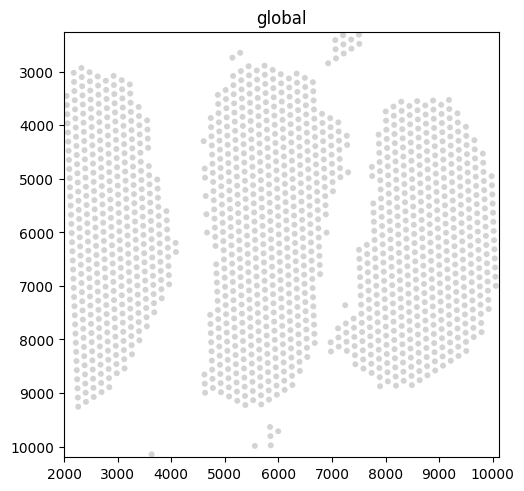

In [9]:
sdata.pl.render_shapes("C26T17").pl.show()

Osserviamo le immagini:

In [10]:
# tipo immagine
type(sdata["C26T17_merge"])
# Come prednere le immagini, ogni immagine ha più scale (la prima più pixel)
sdata.images["C26T17_full_image"]["scale0"]

KeyError: 'C26T17_full_image'

In [ ]:
sdata.images["C26T17_full_image"]

DataTree('None', parent=None)
├── DataTree('scale0')
│       Dimensions:  (c: 3, y: 15279, x: 14894)
│       Coordinates:
│         * c        (c) int64 0 1 2
│         * y        (y) float64 0.5 1.5 2.5 3.5 ... 1.528e+04 1.528e+04 1.528e+04
│         * x        (x) float64 0.5 1.5 2.5 3.5 ... 1.489e+04 1.489e+04 1.489e+04
│       Data variables:
│           image    (c, y, x) uint8 dask.array<chunksize=(3, 15279, 14894), meta=np.ndarray>
├── DataTree('scale1')
│       Dimensions:  (c: 3, y: 7639, x: 7447)
│       Coordinates:
│         * c        (c) int64 0 1 2
│         * y        (y) float64 1.0 3.0 5.0 7.0 ... 1.527e+04 1.528e+04 1.528e+04
│         * x        (x) float64 1.0 3.0 5.0 7.0 ... 1.489e+04 1.489e+04 1.489e+04
│       Data variables:
│           image    (c, y, x) uint8 dask.array<chunksize=(3, 7639, 7447), meta=np.ndarray>
├── DataTree('scale2')
│       Dimensions:  (c: 3, y: 3819, x: 3723)
│       Coordinates:
│         * c        (c) int64 0 1 2
│         * y        (y) float64 2.0 6.001 10.0 14.0 ... 1.527e+04 1.527e+04 1.528e+04
│         * x        (x) float64 2.0 6.001 10.0 14.0 ... 1.488e+04 1.489e+04 1.489e+04
│       Data variables:
│           image    (c, y, x) uint8 dask.array<chunksize=(3, 3819, 3723), meta=np.ndarray>
├── DataTree('scale3')
│       Dimensions:  (c: 3, y: 1909, x: 1861)
│       Coordinates:
│         * c        (c) int64 0 1 2
│         * y        (y) float64 4.002 12.01 20.01 ... 1.526e+04 1.527e+04 1.527e+04
│         * x        (x) float64 4.002 12.0 20.01 ... 1.487e+04 1.488e+04 1.489e+04
│       Data variables:
│           image    (c, y, x) uint8 dask.array<chunksize=(3, 1909, 1861), meta=np.ndarray>
└── DataTree('scale4')
        Dimensions:  (c: 3, y: 954, x: 930)
        Coordinates:
          * c        (c) int64 0 1 2
          * y        (y) float64 8.008 24.02 40.04 ... 1.524e+04 1.525e+04 1.527e+04
          * x        (x) float64 8.008 24.02 40.04 ... 1.485e+04 1.487e+04 1.489e+04
        Data variables:
            image    (c, y, x) uint8 dask.array<chunksize=(3, 954, 930), meta=np.ndarray>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


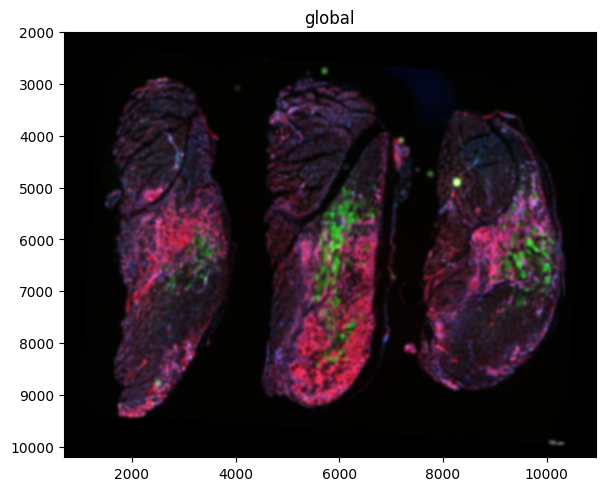

In [ ]:
sdata.pl.render_images(elements="C26T17_merge").pl.show()

INFO     Dropping coordinate system 'downscaled_lowres' since it doesn't have relevant elements.                   
INFO     Dropping coordinate system 'downscaled_hires' since it doesn't have relevant elements.                    
INFO     Dropping coordinate system 'downscaled_lowres' since it doesn't have relevant elements.                   
INFO     Dropping coordinate system 'downscaled_hires' since it doesn't have relevant elements.                    


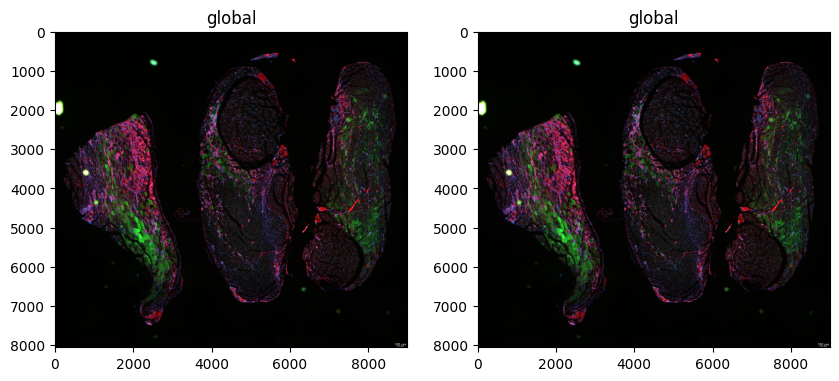

In [26]:
axes = plt.subplots(1, 2, figsize=(10, 5))[1]
sdata.pl.render_images(elements="C26T16_merge").pl.show(ax = axes[0])
sdata.pl.render_images(elements="C26T16_merge", scale="scale4").pl.show(ax = axes[1])


In [27]:
sdata["C26T16_GFP"]

DataTree('None', parent=None)
├── DataTree('scale0')
│       Dimensions:  (c: 3, y: 8057, x: 8991)
│       Coordinates:
│         * c        (c) int64 0 1 2
│         * y        (y) float64 0.5 1.5 2.5 3.5 ... 8.054e+03 8.056e+03 8.056e+03
│         * x        (x) float64 0.5 1.5 2.5 3.5 ... 8.988e+03 8.99e+03 8.99e+03
│       Data variables:
│           image    (c, y, x) uint8 dask.array<chunksize=(3, 256, 256), meta=np.ndarray>
├── DataTree('scale1')
│       Dimensions:  (c: 3, y: 4028, x: 4495)
│       Coordinates:
│         * c        (c) int64 0 1 2
│         * y        (y) float64 1.0 3.0 5.001 7.001 ... 8.052e+03 8.054e+03 8.056e+03
│         * x        (x) float64 1.0 3.0 5.001 7.001 ... 8.986e+03 8.988e+03 8.99e+03
│       Data variables:
│           image    (c, y, x) uint8 dask.array<chunksize=(3, 256, 256), meta=np.ndarray>
├── DataTree('scale2')
│       Dimensions:  (c: 3, y: 2014, x: 2247)
│       Coordinates:
│         * c        (c) int64 0 1 2
│         * y        (y) float64 2.0 6.001 10.0 14.0 ... 8.047e+03 8.051e+03 8.055e+03
│         * x        (x) float64 2.001 6.002 10.0 14.0 ... 8.981e+03 8.985e+03 8.989e+03
│       Data variables:
│           image    (c, y, x) uint8 dask.array<chunksize=(3, 256, 256), meta=np.ndarray>
├── DataTree('scale3')
│       Dimensions:  (c: 3, y: 1007, x: 1123)
│       Coordinates:
│         * c        (c) int64 0 1 2
│         * y        (y) float64 4.0 12.0 20.0 28.0 ... 8.037e+03 8.045e+03 8.053e+03
│         * x        (x) float64 4.003 12.01 20.02 ... 8.971e+03 8.979e+03 8.987e+03
│       Data variables:
│           image    (c, y, x) uint8 dask.array<chunksize=(3, 256, 256), meta=np.ndarray>
└── DataTree('scale4')
        Dimensions:  (c: 3, y: 503, x: 561)
        Coordinates:
          * c        (c) int64 0 1 2
          * y        (y) float64 8.009 24.03 40.04 ... 8.017e+03 8.033e+03 8.049e+03
          * x        (x) float64 8.013 24.04 40.07 ... 8.951e+03 8.967e+03 8.983e+03
        Data variables:
            image    (c, y, x) uint8 dask.array<chunksize=(3, 256, 256), meta=np.ndarray>

# Osservo l'oggetto Table (AnnData)

In [28]:
sdata["table"]

AnnData object with n_obs × n_vars = 1239 × 19465
    obs: 'in_tissue', 'array_row', 'array_col', 'spot_id', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'spatialdata_attrs'
    obsm: 'spatial'

L'oggettto Anndata contiene in *obs* il nome dello spot come node di riga e 

In [14]:
print("Osserviamo prime righe: ")
print(sdata["table"].obs.head(5))
print("\n")
print("Osserviamo dimensione totale:")
(sdata["table"].obs).shape


Osserviamo prime righe: 
                    in_tissue  array_row  array_col  spot_id  region
AAACACCAATAACTGC-1          1         59         19        0  C26T17
AAACAGGGTCTATATT-1          1         47         13        1  C26T17
AAACAGTGTTCCTGGG-1          1         73         43        2  C26T17
AAACCGTTCGTCCAGG-1          1         52         42        3  C26T17
AAACCTCATGAAGTTG-1          1         37         19        4  C26T17


Osserviamo dimensione totale:


(1393, 5)

In [15]:
sdata["table"].obs.nunique()

in_tissue       1
array_row      52
array_col      86
spot_id      1393
region          1
dtype: int64

Oggetto *var* clnstiene l'elenco dei geni

In [16]:
sdata["table"].var

,gene_ids,feature_types,genome
Xkr4,ENSMUSG00000051951,Gene Expression,mm10
Rp1,ENSMUSG00000025900,Gene Expression,mm10
Sox17,ENSMUSG00000025902,Gene Expression,mm10
Lypla1,ENSMUSG00000025903,Gene Expression,mm10
Tcea1,ENSMUSG00000033813,Gene Expression,mm10
...,...,...,...
Zfy2,ENSMUSG00000000103,Gene Expression,mm10
Sry,ENSMUSG00000069036,Gene Expression,mm10
Gm4064,ENSMUSG00000102053,Gene Expression,mm10
Gm3376,ENSMUSG00000096520,Gene Expression,mm10


Oggetto *uns* non capisco,

Sembrano info  generali e basta

In [17]:
sdata["table"].uns

{'spatial': {'C26T17': {'metadata': {'chemistry_description': 'Visium V1 Slide',
    'software_version': 'spaceranger-2.1.1'}}},
 'spatialdata_attrs': {'instance_key': 'spot_id',
  'region': 'C26T17',
  'region_key': 'region'}}

Oggetto *obsm* sembra essere la posizione degli spot. Però ce l'ho gia in *sdata["C3T5"]* quella corretta. Ho quella iniziale poichè ho girato loro e non le immagili fluoroescenti

In [18]:
print(sdata["table"].obsm["spatial"])
print(len(sdata["table"].obsm["spatial"]))
type(sdata["table"].obsm)

[[4737 3866]
 [6499 3287]
 [2736 5991]
 ...
 [4624 4810]
 [6841 4471]
 [2729 5820]]
1393


anndata._core.aligned_mapping.AxisArrays

In [19]:
type(sdata["C26T17"])

geopandas.geodataframe.GeoDataFrame

Aggiorniamo l'oggetto obsm perchè ho le posizioni vecchie degli spot

In [20]:
print(sdata["C26T17"]["geometry"].head(5))
print("\n")
type(sdata["C26T17"]["geometry"])


0    POINT (4737.000 3866.000)
1    POINT (6499.000 3287.000)
2    POINT (2736.000 5991.000)
3    POINT (5849.000 5789.000)
4    POINT (8003.000 3744.000)
Name: geometry, dtype: geometry




geopandas.geoseries.GeoSeries

In [30]:
import numpy as np

x_coords = sdata["C26T16"]["geometry"].x
y_coords = sdata["C26T16"]["geometry"].y

coordinates=np.column_stack((x_coords, y_coords))
#coordinates = np.column_stack((x_coords, y_coords))

# Stampa l'array risultante
coordinates

array([[6417., 3244.],
       [2652., 5949.],
       [7207., 4496.],
       ...,
       [4876., 5780.],
       [6759., 4428.],
       [2646., 5778.]])

In [31]:
sdata["table"].obsm["spatial"] = coordinates
sdata["table"].obsm["spatial"]

array([[6417., 3244.],
       [2652., 5949.],
       [7207., 4496.],
       ...,
       [4876., 5780.],
       [6759., 4428.],
       [2646., 5778.]])

# Trasformiamo SpatialData in image container

In [32]:
adata = to_legacy_anndata(sdata, include_images=True, coordinate_system="global")

/home/stefano/.local/lib/python3.10/site-packages/spatialdata/_core/query/relational_query.py:325: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups_df = table.obs.groupby(by=region_column_name)


WARNING  The vector part of the transformation matrix is not isotropic, the radius will be scaled by the average of
         the modules of eigenvalues of the affine transformation matrix.                                           
         matrix=[[0.13093081 0.         0.        ]                                                                
          [0.         0.13095004 0.        ]                                                                       
          [0.         0.         1.        ]]                                                                      
         eigenvalues=[0.13093081 0.13095004]                                                                       
         scale_factor=0.1309404262857573                                                                           
WARNING  The vector part of the transformation matrix is not isotropic, the radius will be scaled by the average of
         the modules of eigenvalues of the affine transformation matrix.

In [33]:
adata

AnnData object with n_obs × n_vars = 1239 × 19465
    obs: 'in_tissue', 'array_row', 'array_col', 'spot_id', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'spatialdata_attrs'
    obsm: 'spatial'

In [34]:
adata.uns

{'spatial': {'C26T16': {'metadata': {'chemistry_description': 'Visium V1 Slide',
    'software_version': 'spaceranger-2.1.1'}},
  'C26T16_GFP': {'images': {'hires': array([[[0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            ...,
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0]],
    
           [[0, 1, 0],
            [0, 0, 0],
            [0, 0, 0],
            ...,
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0]],
    
           [[0, 1, 0],
            [0, 2, 0],
            [0, 2, 0],
            ...,
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0]],
    
           ...,
    
           [[0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            ...,
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0]],
    
           [[0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            ...,
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0]],
    
           [[

In [35]:
adata.uns["spatial"]["C26T16_full_image"]

{'images': {'hires': array([[[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         ...,
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]]], dtype=uint8),
  'lowres': array([[[  0,   0,   0],
          [136, 130, 127],
          [137, 13


# Estrazione informazioni dall'oggetto adata


In [36]:
sdata.shapes

{'C26T16':                        geometry     radius
0     POINT (6417.000 3244.000)  55.512907
1     POINT (2652.000 5949.000)  55.512907
2     POINT (7207.000 4496.000)  55.512907
3     POINT (5767.000 5747.000)  55.512907
4     POINT (8410.000 8810.000)  55.512907
...                         ...        ...
1234  POINT (2165.000 4856.000)  55.512907
1235  POINT (8998.000 8617.000)  55.512907
1236  POINT (4876.000 5780.000)  55.512907
1237  POINT (6759.000 4428.000)  55.512907
1238  POINT (2646.000 5778.000)  55.512907

[1239 rows x 2 columns]}

In [37]:
adata.obs


,in_tissue,array_row,array_col,spot_id,region
AAACAGGGTCTATATT-1,1,47,13,0,C26T16
AAACAGTGTTCCTGGG-1,1,73,43,1,C26T16
AAACCGGGTAGGTACC-1,1,42,28,2,C26T16
AAACCGTTCGTCCAGG-1,1,52,42,3,C26T16
AAACGAGACGGTTGAT-1,1,35,79,4,C26T16
...,...,...,...,...,...
TTGTTGGCAATGACTG-1,1,76,30,1234,C26T16
TTGTTGTGTGTCAAGA-1,1,31,77,1235,C26T16
TTGTTTCACATCCAGG-1,1,58,42,1236,C26T16
TTGTTTCCATACAACT-1,1,45,27,1237,C26T16


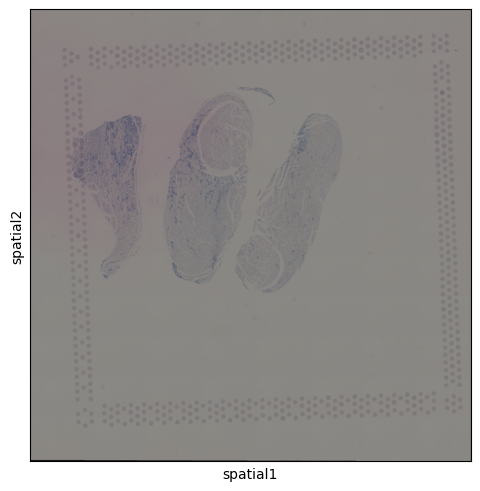

In [ ]:
sq.pl.spatial_scatter(adata, library_id = "C26T16_full_image")

In [30]:
type(adata.uns["spatial"])

dict

In [31]:
adata.uns.keys()

dict_keys(['spatial', 'spatialdata_attrs', 'region_colors'])

In [32]:
adata.uns["spatial"].keys()


dict_keys(['C26T17', 'C26T17_GFP', 'C26T17_WGA', 'C26T17_dapi', 'C26T17_merge'])

Osservo le immagini dell'oggetto adata, sono dizionari comporti da image e scalefactor

In [33]:
print(adata.uns["spatial"]["C26T17_merge"].keys())
print(adata.uns["spatial"]["C26T17_merge"]["images"])

dict_keys(['images', 'scalefactors'])
{'hires': array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8), 'lowres': array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 

In [34]:
adata.obsm["spatial"]

array([[ 987.65704389,  456.74275072],
       [1416.7851491 ,  315.72959924],
       [ 500.32143746,  974.2780649 ],
       ...,
       [ 960.13634247,  686.65020323],
       [1500.07789143,  604.08809899],
       [ 498.61661525,  932.63169373]])

Cosa contiene l'oggetto adata:
- `obs`: info sugli spot come coordinate
- `var`: lista geni 
- `uns["spatia]`: array immamgini
- `obsm`: coordinate spot

## Creo l'oggetto ImageContainer

In [35]:
adata.uns["spatial"]["C26T17_GFP"]["images"]["hires"].shape

(2000, 2500, 3)

In [36]:
x = sdata["C26T17_GFP"]["scale0"].to_dataset()


In [37]:
x["image"].transpose("y", "x", "c")


<xarray.DataArray 'image' (y: 8212, x: 10265, c: 3)>
dask.array<transpose, shape=(8212, 10265, 3), dtype=uint8, chunksize=(8212, 10265, 3), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) int64 0 1 2
  * y        (y) float64 0.5 1.5 2.5 3.5 ... 8.21e+03 8.21e+03 8.212e+03
  * x        (x) float64 0.5 1.5 2.5 3.5 ... 1.026e+04 1.026e+04 1.026e+04
Attributes:
    transform:  {'global': Translation (c, y, x)\n    [   0.         1990.614...

In [38]:
adata.uns["spatial"]["C26T17_merge"]["images"]["hires"].shape

(2000, 2500, 3)

In [39]:
sdata["C26T17_GFP"]["scale0"].to_dataset()["image"].transpose("y","x", "c").rename({"c":"channels"}).values.shape

(8212, 10265, 3)

In [40]:
# tengo anche full _imga
# img2 = sq.im.ImageContainer(adata.uns["spatial"]["C26T17_merge"]["images"]["hires"], layer="C26T17_merge")
# img2.add_img(adata.uns["spatial"]["C26T17_full_image"]["images"]["hires"], layer="C26T17_full_image")
# img2.add_img(adata.uns["spatial"]["C26T17_GFP"]["images"]["hires"], layer="C26T17_GFP")
# img2.add_img(adata.uns["spatial"]["C26T17_WGA"]["images"]["hires"], layer="C26T17_WGA")
# img2.add_img(adata.uns["spatial"]["C26T17_dapi"]["images"]["hires"], layer="C26T17_dapi")


# img2


In [41]:
sdata["C26T17_merge"]["scale0"].to_dataset()["image"].transpose("y","x", "c").rename({"c":"channel"}).values.shape

(8212, 10265, 3)

In [42]:
sdata["C26T17_GFP"]["scale0"].to_dataset()["image"].transpose("y","x", "c").rename({"c":"channel"}).values.shape

(8212, 10265, 3)

Non considero full_image

In [43]:

img = sq.im.ImageContainer(sdata["C26T17_merge"]["scale0"].to_dataset()["image"].transpose("y","x", "c").rename({"c":"channel"}).values,
                           layer="C26T17_merge")
# img.add_img(sdata["C26T17_full_image"]["scale0"].to_dataset()["image"].transpose("y","x", "c").rename({"c":"channel"}).values,
#             layer="C26T17_full_image")
img.add_img(sdata["C26T17_GFP"]["scale0"].to_dataset()["image"].transpose("y","x", "c").rename({"c":"channel"}).values, 
            layer="C26T17_GFP")
img.add_img(sdata["C26T17_WGA"]["scale0"].to_dataset()["image"].transpose("y","x", "c").rename({"c":"channel"}).values, 
            layer="C26T17_WGA")
img.add_img(sdata["C26T17_dapi"]["scale0"].to_dataset()["image"].transpose("y","x", "c").rename({"c":"channel"}).values, 
            layer="C26T17_dapi")
img

/home/stefano/.local/lib/python3.10/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


ImageContainer[shape=(8212, 10265), layers=['C26T17_GFP', 'C26T17_WGA', 'C26T17_dapi', 'C26T17_merge']]

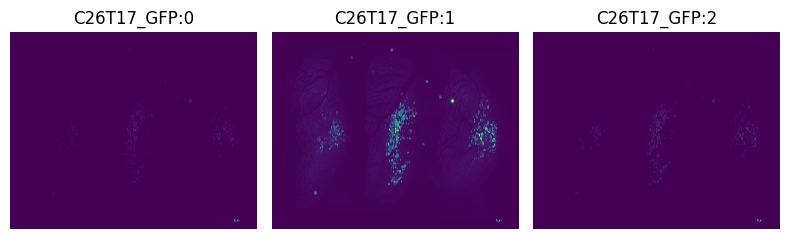

In [44]:
img.show(layer="C26T17_GFP", channelwise=True)

/home/stefano/.local/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)


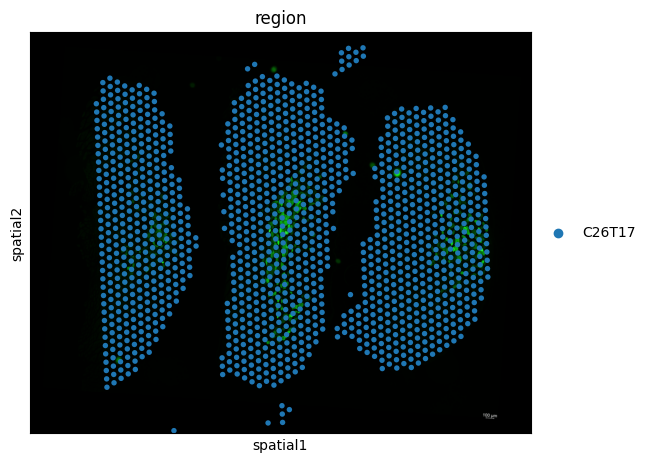

In [45]:
sq.pl.spatial_scatter(adata, library_id = "C26T17_GFP", color="region")

# Segmentazione ed estrazione features


In [40]:
# layer = "C26T17_merge"


# sq.im.process(
#     img=img,
#     layer= layer,
#     method="smooth",
# )

# layer1 = layer + "_" + "smooth"
# layer2 = layer + "_" + "segment"

# sq.im.segment(img=img, layer=layer1, method="watershed", channel=0, chunks=1000, layer_added=layer2)

# fig, ax = plt.subplots(1, 2)
# img_crop = img.crop_corner(1000, 1000, size=500)
# img_crop.show(layer=layer, channel=0, ax=ax[0])
# img_crop.show(
#     layer=layer2,
#     channel=0,
#     ax=ax[1],
# )

# img
# y
# # calculate segmentation features
# key_added = layer + "_segmentation"
# key_added

# sq.im.calculate_image_features(
#     adata,
#     img,
#     layer=layer,
#     library_id = layer,
#     features="segmentation",
#     key_added=key_added,
#     n_jobs=1,
#     features_kwargs={
#         "segmentation": {
#             "label_layer": layer2,
#             "props": ["label", "area", "mean_intensity"]
#         }
#     },
#     mask_circle=True
# )


# adata.obsm["C26T17_merge_segmentation"]





In [53]:
def segmentation_features_extraction(img, adata, layer):
    
    key_added = layer + "_segmentation"
    key_added

    sq.im.calculate_image_features(
        adata,
        img,
        layer=layer,
        library_id = layer,
        features="segmentation",
        key_added=key_added,
        n_jobs=1,
        features_kwargs={
            "segmentation": {
                "label_layer": layer,
                "props": ["label", "area", "mean_intensity"]
            }
        },
        mask_circle=True,
        spot_diameter_key="spot_diameter_fullres"
    )
        
    return (img, adata)

In [47]:
img["C26T17_GFP"]

<xarray.DataArray 'C26T17_GFP' (y: 8212, x: 10265, z: 1, channels: 3)>
array([[[[0, 0, 0]],

        [[0, 0, 0]],

        [[0, 0, 0]],

        ...,

        [[0, 0, 0]],

        [[0, 0, 0]],

        [[0, 0, 0]]],


       [[[0, 0, 0]],

        [[0, 0, 0]],

        [[0, 0, 0]],
...
        [[0, 0, 0]],

        [[0, 0, 0]],

        [[0, 0, 0]]],


       [[[0, 0, 0]],

        [[0, 0, 0]],

        [[0, 0, 0]],

        ...,

        [[0, 0, 0]],

        [[0, 0, 0]],

        [[0, 0, 0]]]], dtype=uint8)
Coordinates:
  * z        (z) <U1 '0'
Dimensions without coordinates: y, x, channels

In [48]:
adata.uns["spatial"].keys()

dict_keys(['C26T17', 'C26T17_GFP', 'C26T17_WGA', 'C26T17_dapi', 'C26T17_merge'])

In [54]:
x = ('C26T17_GFP', 'C26T17_WGA', 'C26T17_dapi', 'C26T17_merge') # "full_image"
for el in x:
    print(el)
    (img, adata) = segmentation_features_extraction(img, adata, el)


C26T17_GFP


  0%|          | 0/1393 [00:00<?, ?/s]/home/stefano/.local/lib/python3.10/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarnin

C26T17_WGA


  0%|          | 0/1393 [00:00<?, ?/s]/home/stefano/.local/lib/python3.10/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarnin

C26T17_dapi


  0%|          | 0/1393 [00:00<?, ?/s]/home/stefano/.local/lib/python3.10/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarnin

C26T17_merge


  0%|          | 0/1393 [00:00<?, ?/s]/home/stefano/.local/lib/python3.10/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/stefano/.local/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarnin

Osservo se è andato a buon fine

In [55]:
print(img)
print(adata.obsm)

ImageContainer[shape=(8212, 10265), layers=['C26T17_GFP', 'C26T17_WGA', 'C26T17_dapi', 'C26T17_merge']]
AxisArrays with keys: spatial, C26T17_GFP_segmentation, C26T17_WGA_segmentation, C26T17_dapi_segmentation, C26T17_merge_segmentation


/home/stefano/.local/lib/python3.10/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


In [57]:
adata.obsm["C26T17_GFP_segmentation"].dropna()

,segmentation_label,segmentation_area_mean,segmentation_area_std,segmentation_ch-0_mean_intensity_mean,segmentation_ch-0_mean_intensity_std,segmentation_ch-1_mean_intensity_mean,segmentation_ch-1_mean_intensity_std,segmentation_ch-2_mean_intensity_mean,segmentation_ch-2_mean_intensity_std
AAATACCTATAAGCAT-1,1,2.0,0.0,1.0,0.0,5.000000,0.0,0.0,0.0
AAATTAACGGGTAGCT-1,1,1.0,0.0,1.0,0.0,5.000000,0.0,0.0,0.0
AACCTTTAAATACGGT-1,1,3.0,0.0,1.0,0.0,6.333333,0.0,0.0,0.0
AACGTGCGAAAGTCTC-1,1,18.0,0.0,1.0,0.0,7.833333,0.0,0.0,0.0
AACTCAAGTTAATTGC-1,1,14.0,0.0,1.0,0.0,7.500000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
TTGAATATGGACTTTC-1,1,7.0,0.0,1.0,0.0,7.714286,0.0,0.0,0.0
TTGACATGAACGTGGA-1,1,1.0,0.0,1.0,0.0,2.000000,0.0,0.0,0.0
TTGCTGATCATGTTCG-1,1,21.0,0.0,1.0,0.0,8.238095,0.0,0.0,0.0
TTGGAAGAATACAGTC-1,1,3.0,0.0,1.0,0.0,3.000000,0.0,0.0,0.0


In [52]:
adata.obsm["C26T17_merge_segmentation"]

,segmentation_label,segmentation_area_mean,segmentation_area_std,segmentation_ch-0_mean_intensity_mean,segmentation_ch-0_mean_intensity_std,segmentation_ch-1_mean_intensity_mean,segmentation_ch-1_mean_intensity_std,segmentation_ch-2_mean_intensity_mean,segmentation_ch-2_mean_intensity_std
AAACACCAATAACTGC-1,3,176.333333,124.430257,2.0,0.816497,2.953549,0.036173,1.462658,0.092025
AAACAGGGTCTATATT-1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACAGTGTTCCTGGG-1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACCGTTCGTCCAGG-1,3,176.333333,176.598100,3.0,0.816497,3.857271,0.036655,2.009101,0.083019
AAACCTCATGAAGTTG-1,4,132.250000,131.767551,2.5,1.118034,3.496352,0.295854,1.663980,0.383445
...,...,...,...,...,...,...,...,...,...
TTGTTGGCAATGACTG-1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TTGTTTCACATCCAGG-1,3,176.333333,166.101040,3.0,0.816497,3.487351,0.120940,1.718224,0.079010
TTGTTTCATTAGTCTA-1,3,176.333333,123.110610,3.0,0.816497,3.295220,0.235493,1.321216,0.246493
TTGTTTCCATACAACT-1,3,176.333333,125.979716,3.0,0.816497,3.587932,0.077403,1.985953,0.023986


In [ ]:
GFP = adata.obsm["C26T17_GFP_segmentation"]
merge = adata.obsm["C26T17_merge_segmentation"]
full = adata.obsm["C26T17_full_image_segmentation"]
WGA = adata.obsm["C26T17_WGA_segmentation"]
dapi = adata.obsm["C26T17_dapi_segmentation"]



GFP.columns

Index(['segmentation_label', 'segmentation_area_mean', 'segmentation_area_std',
       'segmentation_ch-0_mean_intensity_mean',
       'segmentation_ch-0_mean_intensity_std',
       'segmentation_ch-1_mean_intensity_mean',
       'segmentation_ch-1_mean_intensity_std',
       'segmentation_ch-2_mean_intensity_mean',
       'segmentation_ch-2_mean_intensity_std'],
      dtype='object')

In [ ]:
GFP = GFP.rename(columns={
    'segmentation_label': "label", 
    'segmentation_area_mean': "mean_area", 
    'segmentation_area_std': "std_area",
    'segmentation_ch-0_mean_intensity_mean' : "ch0_mean",
    'segmentation_ch-0_mean_intensity_std' : "ch0_std",
    'segmentation_ch-1_mean_intensity_mean' : "ch1_mean",
    'segmentation_ch-1_mean_intensity_std': "ch1_std",
    'segmentation_ch-2_mean_intensity_mean' : "ch2_mean",
    'segmentation_ch-2_mean_intensity_std' : "ch2_std",
})

merge = merge.rename(columns={
    'segmentation_label': "label", 
    'segmentation_area_mean': "mean_area", 
    'segmentation_area_std': "std_area",
    'segmentation_ch-0_mean_intensity_mean' : "ch0_mean",
    'segmentation_ch-0_mean_intensity_std' : "ch0_std",
    'segmentation_ch-1_mean_intensity_mean' : "ch1_mean",
    'segmentation_ch-1_mean_intensity_std': "ch1_std",
    'segmentation_ch-2_mean_intensity_mean' : "ch2_mean",
    'segmentation_ch-2_mean_intensity_std' : "ch2_std",
})

full = full.rename(columns={
    'segmentation_label': "label", 
    'segmentation_area_mean': "mean_area", 
    'segmentation_area_std': "std_area",
    'segmentation_ch-0_mean_intensity_mean' : "ch0_mean",
    'segmentation_ch-0_mean_intensity_std' : "ch0_std",
    'segmentation_ch-1_mean_intensity_mean' : "ch1_mean",
    'segmentation_ch-1_mean_intensity_std': "ch1_std",
    'segmentation_ch-2_mean_intensity_mean' : "ch2_mean",
    'segmentation_ch-2_mean_intensity_std' : "ch2_std",
})

WGA = WGA.rename(columns={
    'segmentation_label': "label", 
    'segmentation_area_mean': "mean_area", 
    'segmentation_area_std': "std_area",
    'segmentation_ch-0_mean_intensity_mean' : "ch0_mean",
    'segmentation_ch-0_mean_intensity_std' : "ch0_std",
    'segmentation_ch-1_mean_intensity_mean' : "ch1_mean",
    'segmentation_ch-1_mean_intensity_std': "ch1_std",
    'segmentation_ch-2_mean_intensity_mean' : "ch2_mean",
    'segmentation_ch-2_mean_intensity_std' : "ch2_std",
})

dapi = dapi.rename(columns={
    'segmentation_label': "label", 
    'segmentation_area_mean': "mean_area", 
    'segmentation_area_std': "std_area",
    'segmentation_ch-0_mean_intensity_mean' : "ch0_mean",
    'segmentation_ch-0_mean_intensity_std' : "ch0_std",
    'segmentation_ch-1_mean_intensity_mean' : "ch1_mean",
    'segmentation_ch-1_mean_intensity_std': "ch1_std",
    'segmentation_ch-2_mean_intensity_mean' : "ch2_mean",
    'segmentation_ch-2_mean_intensity_std' : "ch2_std",
})


In [ ]:
# GFP.dropna()

,label,mean_area,std_area,ch0_mean,ch0_std,ch1_mean,ch1_std,ch2_mean,ch2_std
AAACCGTTCGTCCAGG-1,9,16.555556,21.297423,10.000000,2.581989,154.916767,30.757040,18.898281,4.577573
AAAGGCTCTCGCGCCG-1,3,15.666667,18.660713,2.333333,1.247219,50.630952,19.480723,5.067460,2.275903
AAATTTGCGGGTGTGG-1,5,12.600000,8.114185,3.000000,1.414214,46.503269,18.167694,5.039425,2.361912
AACAACTGGTAGTTGC-1,11,12.363636,15.221234,6.000000,3.162278,99.262417,42.733777,10.456332,5.328161
AACCCGACAACCCGTG-1,1,2.000000,0.000000,1.000000,0.000000,16.500000,0.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...
TTGCCCTGATCACGGG-1,1,2.000000,0.000000,1.000000,0.000000,24.000000,0.000000,0.500000,0.000000
TTGCGGCATCAGAAAG-1,7,15.857143,10.575289,4.000000,2.000000,70.796862,26.123022,7.396933,3.199220
TTGCGTCGGCCAACCG-1,11,9.000000,8.124038,6.000000,3.162278,97.925988,43.216178,11.073502,5.661662
TTGGTCACACTCGTAA-1,1,2.000000,0.000000,1.000000,0.000000,19.000000,0.000000,1.500000,0.000000


In [ ]:
x = {"GFP":GFP, "WGA": WGA, "merge":merge, "dapi":dapi, "full":full}

for el in x:
    x[el].columns = el + "_" + x[el].columns

In [ ]:
GFP

,GFP_label,GFP_mean_area,GFP_std_area,GFP_ch0_mean,GFP_ch0_std,GFP_ch1_mean,GFP_ch1_std,GFP_ch2_mean,GFP_ch2_std
AAACACCAATAACTGC-1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACAGGGTCTATATT-1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACAGTGTTCCTGGG-1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACCGTTCGTCCAGG-1,9,16.555556,21.297423,10.0,2.581989,154.916767,30.75704,18.898281,4.577573
AAACCTCATGAAGTTG-1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
TTGTTGGCAATGACTG-1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TTGTTTCACATCCAGG-1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TTGTTTCATTAGTCTA-1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TTGTTTCCATACAACT-1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# seleziono le colonne crelative al colore

GFP = GFP[GFP.columns[3:9]]
dapi = dapi[dapi.columns[3:9]]
WGA = WGA[WGA.columns[3:9]]
merge = merge[merge.columns[3:9]]
full = full[full.columns[3:9]]

In [ ]:
df = GFP.merge(dapi, left_index = True, right_index=True)
df = df.merge(WGA, left_index = True, right_index=True)
df = df.merge(merge, left_index = True, right_index=True)
df = df.merge(full, left_index = True, right_index=True)

df

,GFP_ch0_mean,GFP_ch0_std,GFP_ch1_mean,GFP_ch1_std,GFP_ch2_mean,GFP_ch2_std,dapi_ch0_mean,dapi_ch0_std,dapi_ch1_mean,dapi_ch1_std,...,merge_ch1_mean,merge_ch1_std,merge_ch2_mean,merge_ch2_std,full_ch0_mean,full_ch0_std,full_ch1_mean,full_ch1_std,full_ch2_mean,full_ch2_std
AAACACCAATAACTGC-1,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,1.118034,26.875000,10.249238,...,20.393533,21.545659,23.861291,25.030660,113.470588,17.550323,111.293871,12.531247,121.699352,4.843600
AAACAGGGTCTATATT-1,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.816497,29.138889,10.345945,...,12.444714,11.951680,15.929897,18.287484,115.647059,16.853839,112.627690,11.767160,121.067735,5.299039
AAACAGTGTTCCTGGG-1,NaN,NaN,NaN,NaN,NaN,NaN,1.500000,0.500000,21.000000,4.000000,...,27.258523,10.898370,48.187500,26.022254,107.025000,14.799472,106.581667,11.089713,119.719077,3.345621
AAACCGTTCGTCCAGG-1,10.0,2.581989,154.916767,30.75704,18.898281,4.577573,2.000000,0.816497,48.458333,19.154072,...,145.842659,15.498846,46.742885,22.087577,106.475000,16.892287,105.493306,11.559867,117.226223,4.677999
AAACCTCATGAAGTTG-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.426742,3.001366,13.412652,7.603421,129.058824,10.657616,121.653137,9.181522,125.326279,4.457806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTGGCAATGACTG-1,NaN,NaN,NaN,NaN,NaN,NaN,1.500000,0.500000,21.687500,5.687500,...,18.116228,9.742990,30.184795,21.341374,116.702703,16.063834,113.736631,11.753325,121.054503,5.200073
TTGTTTCACATCCAGG-1,NaN,NaN,NaN,NaN,NaN,NaN,1.500000,0.500000,19.833333,3.166667,...,11.692115,6.083780,15.137671,10.776939,118.531250,15.475756,114.670969,11.081608,121.751003,4.899648
TTGTTTCATTAGTCTA-1,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.816497,29.750000,7.282971,...,14.928398,7.523071,21.569913,14.000541,122.307692,14.748583,117.749604,10.704868,123.417317,4.974595
TTGTTTCCATACAACT-1,NaN,NaN,NaN,NaN,NaN,NaN,2.666667,1.699673,47.145833,6.765479,...,28.195016,17.648721,52.396977,32.090457,119.722222,13.694304,114.421500,9.178233,120.713514,3.537932


In [ ]:
import pandas as pd

coords = pd.DataFrame(adata.obsm["spatial"])
coords.index = df.index
coords




,0,1
AAACACCAATAACTGC-1,620.192695,506.054061
AAACAGGGTCTATATT-1,850.882906,430.263761
AAACAGTGTTCCTGGG-1,358.211360,784.213627
AAACCGTTCGTCCAGG-1,765.781523,757.772106
AAACCTCATGAAGTTG-1,1047.794414,490.084430
...,...,...
TTGTTGGCAATGACTG-1,294.450786,641.141436
TTGTTTCACATCCAGG-1,649.258091,762.091760
TTGTTTCATTAGTCTA-1,605.398147,629.622357
TTGTTTCCATACAACT-1,895.659326,585.247726


In [ ]:
# print(sdata["C26T17"])
# print(sdata.table.obsm["spatial"])

                       geometry     radius
0     POINT (4737.000 3866.000)  55.488089
1     POINT (6499.000 3287.000)  55.488089
2     POINT (2736.000 5991.000)  55.488089
3     POINT (5849.000 5789.000)  55.488089
4     POINT (8003.000 3744.000)  55.488089
...                         ...        ...
1388  POINT (2249.000 4898.000)  55.488089
1389  POINT (4959.000 5822.000)  55.488089
1390  POINT (4624.000 4810.000)  55.488089
1391  POINT (6841.000 4471.000)  55.488089
1392  POINT (2729.000 5820.000)  55.488089

[1393 rows x 2 columns]
[[4737. 3866.]
 [6499. 3287.]
 [2736. 5991.]
 ...
 [4624. 4810.]
 [6841. 4471.]
 [2729. 5820.]]


/tmp/ipykernel_146995/3303734048.py:2: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  print(sdata.table.obsm["spatial"])


In [ ]:
coords2 = pd.DataFrame(sdata.table.obsm["spatial"])
coords2.index = df.index
coords2.sort_values(by=[0])

/tmp/ipykernel_146995/284203225.py:1: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  coords2 = pd.DataFrame(sdata.table.obsm["spatial"])


,0,1
AGATAATCACACCTAT-1,2046.0,3454.0
TCATGAAGCGCTGCAT-1,2053.0,3624.0
CGACTTGCCGGGAAAT-1,2059.0,3795.0
TGCTCAAAGGATGCAC-1,2065.0,3966.0
ACAAGTAATTGTAAGG-1,2072.0,4136.0
...,...,...
ACACCCAGCATGCAGC-1,10031.0,6316.0
TTACAACTACGCATCC-1,10037.0,6487.0
GGGCGTACATTTATAT-1,10044.0,6657.0
ACACAAAGACGGGTGG-1,10050.0,6828.0


In [ ]:
# coords.sort_values(by=[0])

,0,1
AGATAATCACACCTAT-1,267.872969,452.123830
TCATGAAGCGCTGCAT-1,268.789445,474.376595
CGACTTGCCGGGAAAT-1,269.574997,496.760259
TGCTCAAAGGATGCAC-1,270.360548,519.143923
ACAAGTAATTGTAAGG-1,271.277024,541.396688
...,...,...
ACACCCAGCATGCAGC-1,1313.310729,826.755678
TTACAACTACGCATCC-1,1314.096280,849.139342
GGGCGTACATTTATAT-1,1315.012757,871.392107
ACACAAAGACGGGTGG-1,1315.798308,893.775771


In [ ]:
# print(sum(coords.sort_values(by=[0]).index != coords2.sort_values(by=[0]).index))
# sum(coords.sort_values(by=[1]).index != coords2.sort_values(by=[1]).index)

0


0

In [ ]:
coords = coords.rename(columns={
    0: "X1", 
    1: "Y1", 
})
coords2 = coords2.rename(columns={
    0: "X2", 
    1: "Y2", 
})

In [ ]:
df = df.merge(coords, left_index = True, right_index=True)
df = df.merge(coords2, left_index = True, right_index=True)

In [ ]:
df

,GFP_ch0_mean,GFP_ch0_std,GFP_ch1_mean,GFP_ch1_std,GFP_ch2_mean,GFP_ch2_std,dapi_ch0_mean,dapi_ch0_std,dapi_ch1_mean,dapi_ch1_std,...,full_ch0_mean,full_ch0_std,full_ch1_mean,full_ch1_std,full_ch2_mean,full_ch2_std,X1,Y1,X2,Y2
AAACACCAATAACTGC-1,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,1.118034,26.875000,10.249238,...,113.470588,17.550323,111.293871,12.531247,121.699352,4.843600,620.192695,506.054061,4737.0,3866.0
AAACAGGGTCTATATT-1,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.816497,29.138889,10.345945,...,115.647059,16.853839,112.627690,11.767160,121.067735,5.299039,850.882906,430.263761,6499.0,3287.0
AAACAGTGTTCCTGGG-1,NaN,NaN,NaN,NaN,NaN,NaN,1.500000,0.500000,21.000000,4.000000,...,107.025000,14.799472,106.581667,11.089713,119.719077,3.345621,358.211360,784.213627,2736.0,5991.0
AAACCGTTCGTCCAGG-1,10.0,2.581989,154.916767,30.75704,18.898281,4.577573,2.000000,0.816497,48.458333,19.154072,...,106.475000,16.892287,105.493306,11.559867,117.226223,4.677999,765.781523,757.772106,5849.0,5789.0
AAACCTCATGAAGTTG-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,129.058824,10.657616,121.653137,9.181522,125.326279,4.457806,1047.794414,490.084430,8003.0,3744.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTGGCAATGACTG-1,NaN,NaN,NaN,NaN,NaN,NaN,1.500000,0.500000,21.687500,5.687500,...,116.702703,16.063834,113.736631,11.753325,121.054503,5.200073,294.450786,641.141436,2249.0,4898.0
TTGTTTCACATCCAGG-1,NaN,NaN,NaN,NaN,NaN,NaN,1.500000,0.500000,19.833333,3.166667,...,118.531250,15.475756,114.670969,11.081608,121.751003,4.899648,649.258091,762.091760,4959.0,5822.0
TTGTTTCATTAGTCTA-1,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.816497,29.750000,7.282971,...,122.307692,14.748583,117.749604,10.704868,123.417317,4.974595,605.398147,629.622357,4624.0,4810.0
TTGTTTCCATACAACT-1,NaN,NaN,NaN,NaN,NaN,NaN,2.666667,1.699673,47.145833,6.765479,...,119.722222,13.694304,114.421500,9.178233,120.713514,3.537932,895.659326,585.247726,6841.0,4471.0


In [ ]:
df.to_csv("dati/csv/c26t17_color.csv")

# Un po di info generali per poter capire come fare esplorativa

In [116]:
df[["GFP_ch0_mean", "GFP_ch1_mean", "GFP_ch2_mean"]].dropna().describe()

,GFP_ch0_mean,GFP_ch1_mean,GFP_ch2_mean
count,613.000000,613.000000,613.000000
mean,2.370763,42.879418,3.836651
std,1.795160,27.444150,3.564673
min,1.000000,1.000000,0.000000
25%,1.000000,20.700000,1.000000
50%,2.000000,37.458333,3.125000
75%,3.000000,56.454545,5.483810
max,15.772727,187.551132,25.627254


In [118]:
df.loc[df["GFP_ch1_mean"]>180]

,GFP_ch0_mean,GFP_ch0_std,GFP_ch1_mean,GFP_ch1_std,GFP_ch2_mean,GFP_ch2_std,dapi_ch0_mean,dapi_ch0_std,dapi_ch1_mean,dapi_ch1_std,...,merge_ch1_mean,merge_ch1_std,merge_ch2_mean,merge_ch2_std,full_ch0_mean,full_ch0_std,full_ch1_mean,full_ch1_std,full_ch2_mean,full_ch2_std
AGGCCTATCATACCAA-1,15.444444,10.329151,187.551132,71.448166,25.627254,12.267442,1.0,0.0,24.0,0.0,...,168.024195,71.947736,44.175442,22.038624,108.521739,15.809655,104.754447,11.052406,118.26631,4.18166


In [119]:
df.index

Index(['AAACAGGGTCTATATT-1', 'AAACAGTGTTCCTGGG-1', 'AAACCGGGTAGGTACC-1',
       'AAACCGTTCGTCCAGG-1', 'AAACGAGACGGTTGAT-1', 'AAACGGTTGCGAACTG-1',
       'AAACTTGCAAACGTAT-1', 'AAAGGCCCTATAATAC-1', 'AAAGGCTCTCGCGCCG-1',
       'AAAGGGCAGCTTGAAT-1',
       ...
       'TTGTGAGGCATGACGC-1', 'TTGTGGTAGGAGGGAT-1', 'TTGTGTATGCCACCAA-1',
       'TTGTGTTTCCCGAAAG-1', 'TTGTTAGCAAATTCGA-1', 'TTGTTGGCAATGACTG-1',
       'TTGTTGTGTGTCAAGA-1', 'TTGTTTCACATCCAGG-1', 'TTGTTTCCATACAACT-1',
       'TTGTTTGTATTACACG-1'],
      dtype='object', length=1239)

In [136]:
sdata.table.obs

/tmp/ipykernel_121052/4204772674.py:1: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  sdata.table.obs


,in_tissue,array_row,array_col,spot_id,region
AAACAGGGTCTATATT-1,1,47,13,0,C26T16
AAACAGTGTTCCTGGG-1,1,73,43,1,C26T16
AAACCGGGTAGGTACC-1,1,42,28,2,C26T16
AAACCGTTCGTCCAGG-1,1,52,42,3,C26T16
AAACGAGACGGTTGAT-1,1,35,79,4,C26T16
...,...,...,...,...,...
TTGTTGGCAATGACTG-1,1,76,30,1234,C26T16
TTGTTGTGTGTCAAGA-1,1,31,77,1235,C26T16
TTGTTTCACATCCAGG-1,1,58,42,1236,C26T16
TTGTTTCCATACAACT-1,1,45,27,1237,C26T16
